In [ ]:
# ============================================================
#  Open Food Facts – Erster Überblick
#  Einfach in ein Jupyter Notebook kopieren und Zelle für Zelle ausführen
# ============================================================
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── 0. DATEI LADEN ───────────────────────────────────────────
# Pfad anpassen!
CSV_PATH = "en.openfoodfacts.org.products 2.csv"

# Wir laden zunächst nur die wichtigsten Spalten –
# die volle Datei hat >180 Spalten und mehrere GB.
COLS = [
    "code", "product_name", "countries_en",
    "categories_en", "labels_en",
    "packaging_en",
    "nutriscore_grade", "nutriscore_score",
    "nova_group", "ecoscore_grade",
    "energy-kcal_100g", "fat_100g", "saturated-fat_100g",
    "sugars_100g", "fiber_100g", "proteins_100g", "salt_100g",
    "ingredients_text",
    "created_datetime", "completeness", "carbohydrates_100g", "origins_en"
]

print("⏳ Lade CSV … (kann etwas dauern)")
df = pd.read_csv(
    CSV_PATH,
    sep="\t",           # Open Food Facts nutzt Tab als Trennzeichen
    usecols=COLS,
    low_memory=False,
    on_bad_lines="skip",
)
print(f"✅ Geladen: {df.shape[0]:,} Zeilen  |  {df.shape[1]} Spalten\n")


# ── 1. GRUNDLEGENDE INFOS ────────────────────────────────────
print("=" * 55)
print("1. GRUNDLEGENDE INFOS")
print("=" * 55)
print(df.dtypes)
print()
print(df.describe(include="all").T.reindex(columns=["count","unique","top","mean","std","min","max"]))


# ── 2. FEHLENDE WERTE ────────────────────────────────────────
print("\n" + "=" * 55)
print("2. FEHLENDE WERTE (% der Zeilen)")
print("=" * 55)
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing.to_string())

# Visualisierung: Vollständigkeit (vorhandene Werte)
filled = (100 - missing).sort_values(ascending=True)
colors_mv = ["#d73027" if v < 50 else "#1a9850" for v in filled]
fig, ax = plt.subplots(figsize=(10, 6))
bars_mv = ax.barh(filled.index, filled.values, color=colors_mv, edgecolor="white")
for bar, val in zip(bars_mv, filled.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} %", va="center", fontsize=8)
ax.set_xlabel("Vorhanden (%)")
ax.set_title(f"Anteil vorhandener Werte pro Spalte (n = {len(df):,})")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50 % Grenze")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig("missing_values.png", dpi=150)
plt.show()
print("→ Grafik gespeichert: missing_values.png")


# ── 3. NUTRI-SCORE VERTEILUNG ────────────────────────────────
print("\n" + "=" * 55)
print("3. NUTRI-SCORE VERTEILUNG")
print("=" * 55)
ns = (df["nutriscore_grade"].str.upper()
      .where(lambda x: x.isin(["A","B","C","D","E"]))
      .value_counts().reindex(["A","B","C","D","E"]))
print(ns.to_string())
print(f"\nProdukte MIT Nutri-Score:  {ns.sum():,} ({ns.sum()/len(df)*100:.1f} %)")
print(f"Produkte OHNE Nutri-Score: {df['nutriscore_grade'].isna().sum():,}")

colors_ns = ["#1a9850","#91cf60","#fee08b","#fc8d59","#d73027"]
total_ns = ns.sum()
fig, ax = plt.subplots(figsize=(7, 5))
bars_ns = ax.bar(ns.index, ns.values, color=colors_ns, edgecolor="white", width=0.6)
for bar, count in zip(bars_ns, ns.values):
    pct = count / total_ns * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total_ns * 0.005,
            f"{count:,}\n({pct:.1f} %)", ha="center", va="bottom", fontsize=9)
ax.set_title(f"Nutri-Score Verteilung\n(nur A–E, n = {total_ns:,})", fontsize=12)
ax.set_xlabel("Nutri-Score")
ax.set_ylabel("Anzahl Produkte")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, ns.max() * 1.18)
plt.tight_layout()
plt.savefig("nutriscore_distribution.png", dpi=150)
plt.show()


# ── 4. NOVA-GRUPPE ───────────────────────────────────────────
print("\n" + "=" * 55)
print("4. NOVA-GRUPPE (Verarbeitungsgrad)")
print("=" * 55)
nova_raw = pd.to_numeric(df["nova_group"], errors="coerce")
nova = nova_raw[nova_raw.isin([1, 2, 3, 4])].value_counts().sort_index()
print(nova.rename({1:"1 – Unverarbeitet", 2:"2 – Verarbeitete Zutaten",
                   3:"3 – Verarbeitet", 4:"4 – Ultra-verarbeitet"}).to_string())

labels_nova = {1:"1 – Unverarbeitet", 2:"2 – Verarbeitete Zutaten",
               3:"3 – Verarbeitet", 4:"4 – Ultra-verarbeitet"}
colors_nova = ["#1a9850", "#91cf60", "#fc8d59", "#d73027"]
total_nova = nova.sum()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [labels_nova[i] for i in nova.index],
    nova.values,
    color=colors_nova,
    edgecolor="white",
    width=0.6,
)
for bar, count in zip(bars, nova.values):
    pct = count / total_nova * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total_nova * 0.005,
        f"{count:,}\n({pct:.1f} %)",
        ha="center", va="bottom", fontsize=9,
    )
ax.set_title(f"NOVA-Gruppen Verteilung\n(nur gültige Einträge, n = {total_nova:,})", fontsize=12)
ax.set_ylabel("Anzahl Produkte")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, nova.max() * 1.18)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("nova_distribution.png", dpi=150)
plt.show()


# ── 5. TOP-LÄNDER ────────────────────────────────────────────
print("\n" + "=" * 55)
print("5. TOP 20 LÄNDER (nach Produktanzahl)")
print("=" * 55)
top_countries = (
    df["countries_en"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(20)
)
print(top_countries.to_string())

top_sorted = top_countries.sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
bars_tc = ax.barh(top_sorted.index, top_sorted.values, color="#4393c3", edgecolor="white")
for bar, val in zip(bars_tc, top_sorted.values):
    ax.text(val + top_sorted.max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8)
ax.set_title("Top 20 Länder nach Produktanzahl")
ax.set_xlabel("Anzahl Produkte")
ax.set_xlim(0, top_sorted.max() * 1.12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("top_countries.png", dpi=150)
plt.show()


# ── 6. NÄHRWERTE – ÜBERBLICK ─────────────────────────────────
print("\n" + "=" * 55)
print("6. NÄHRWERTE – ÜBERBLICK (pro 100g)")
print("=" * 55)
nutrients = ["energy-kcal_100g","fat_100g","saturated-fat_100g",
             "sugars_100g","fiber_100g","proteins_100g","salt_100g"]

# Spalten zu Zahlen konvertieren (fehlerhafte Werte werden NaN)
for col in nutrients:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[nutrients].describe().round(2).to_string())

nice_names = ["Energie (kcal)","Fett (g)","Ges. Fettsäuren (g)",
              "Zucker (g)","Ballaststoffe (g)","Proteine (g)","Salz (g)"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, (col, name) in enumerate(zip(nutrients, nice_names)):
    data = df[col].dropna()
    q1, q99 = data.quantile(0.01), data.quantile(0.99)
    clipped = data[(data >= q1) & (data <= q99)]
    axes[i].boxplot(clipped, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#c6dbef"),
                    medianprops=dict(color="#08306b", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    axes[i].set_title(name, fontsize=9)
    axes[i].set_ylabel("pro 100g")
    axes[i].set_xlabel(f"n = {len(clipped):,}", fontsize=7)
axes[-1].axis("off")
plt.suptitle("Nährwert-Verteilungen (1.–99. Perzentile)", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("nutrients_boxplot.png", dpi=150)
plt.show()


# ── 7. ZEITLICHE ENTWICKLUNG ─────────────────────────────────
print("\n" + "=" * 55)
print("7. ZEITLICHE ENTWICKLUNG (Einträge pro Jahr)")
print("=" * 55)
df["year_created"] = pd.to_datetime(
    df["created_datetime"], errors="coerce"
).dt.year
yearly = df["year_created"].value_counts().sort_index()
yearly = yearly[(yearly.index >= 2012) & (yearly.index <= 2025)]
print(yearly.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
bars_yr = ax.bar(yearly.index.astype(str), yearly.values, color="#4393c3", edgecolor="white")
for bar, val in zip(bars_yr, yearly.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + yearly.max() * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=7.5, rotation=45)
ax.set_title("Neu eingetragene Produkte pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl Produkte")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, yearly.max() * 1.2)
plt.tight_layout()
plt.savefig("yearly_entries.png", dpi=150)
plt.show()


# ── 8. VOLLSTÄNDIGKEIT ───────────────────────────────────────
print("\n" + "=" * 55)
print("8. VOLLSTÄNDIGKEIT DER EINTRÄGE")
print("=" * 55)
if "completeness" in df.columns:
    df["completeness"] = pd.to_numeric(df["completeness"], errors="coerce")
    print(df["completeness"].describe().round(3))
    comp = df["completeness"].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    comp.hist(bins=50, ax=ax, color="#4393c3", edgecolor="white")
    ax.axvline(comp.median(), color="#d73027", linewidth=1.5,
               label=f"Median: {comp.median():.2f}")
    ax.axvline(comp.mean(), color="#fc8d59", linewidth=1.5, linestyle="--",
               label=f"Mittelwert: {comp.mean():.2f}")
    ax.set_title(f"Verteilung der Datenvollständigkeit (n = {len(comp):,})")
    ax.set_xlabel("Vollständigkeit (0–1)")
    ax.set_ylabel("Anzahl Produkte")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend()
    plt.tight_layout()
    plt.savefig("completeness.png", dpi=150)
    plt.show()


# ── 9. KURZE ZUSAMMENFASSUNG ─────────────────────────────────
print("\n" + "=" * 55)
print("9. ZUSAMMENFASSUNG FÜR MEILENSTEIN 1")
print("=" * 55)
print(f"Gesamtprodukte:          {len(df):>12,}")
print(f"Produkte mit Name:       {df['product_name'].notna().sum():>12,}  ({df['product_name'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Nutri-Score:{df['nutriscore_grade'].notna().sum():>12,}  ({df['nutriscore_grade'].notna().mean()*100:.1f} %)")
print(f"Produkte mit NOVA-Gruppe:{df['nova_group'].notna().sum():>12,}  ({df['nova_group'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Land:       {df['countries_en'].notna().sum():>12,}  ({df['countries_en'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Nährwerten: {df['energy-kcal_100g'].notna().sum():>12,}  ({df['energy-kcal_100g'].notna().mean()*100:.1f} %)")
print(f"Jahresspanne:            {int(df['year_created'].min())} – {int(df['year_created'].max())}")
print()
print("Alle Grafiken wurden als PNG gespeichert.")
print("Viel Erfolg beim Meilenstein 1! 🚀")

/opt/homebrew/opt/python@3.11/bin/python3.11
⏳ Lade CSV mit wichtigen Spalten …
✅ Geladen: 4,501,357 Zeilen  |  21 Spalten

Vorhandene Werte pro Spalte:
  origins_en                            3.8%  (172,496 vorhanden)
  packaging_en                          8.4%  (378,934 vorhanden)
  fiber_100g                           22.4%  (1,010,215 vorhanden)
  nova_group                           25.1%  (1,129,056 vorhanden)
  labels_en                            27.2%  (1,225,500 vorhanden)
  ingredients_text                     28.5%  (1,280,988 vorhanden)
  nutriscore_score                     30.4%  (1,368,220 vorhanden)
  categories_en                        41.1%  (1,849,387 vorhanden)
  salt_100g                            42.7%  (1,922,304 vorhanden)
  saturated-fat_100g                   46.6%  (2,099,431 vorhanden)
  sugars_100g                          47.0%  (2,114,518 vorhanden)
  fat_100g                             48.4%  (2,177,813 vorhanden)
  carbohydrates_100g               

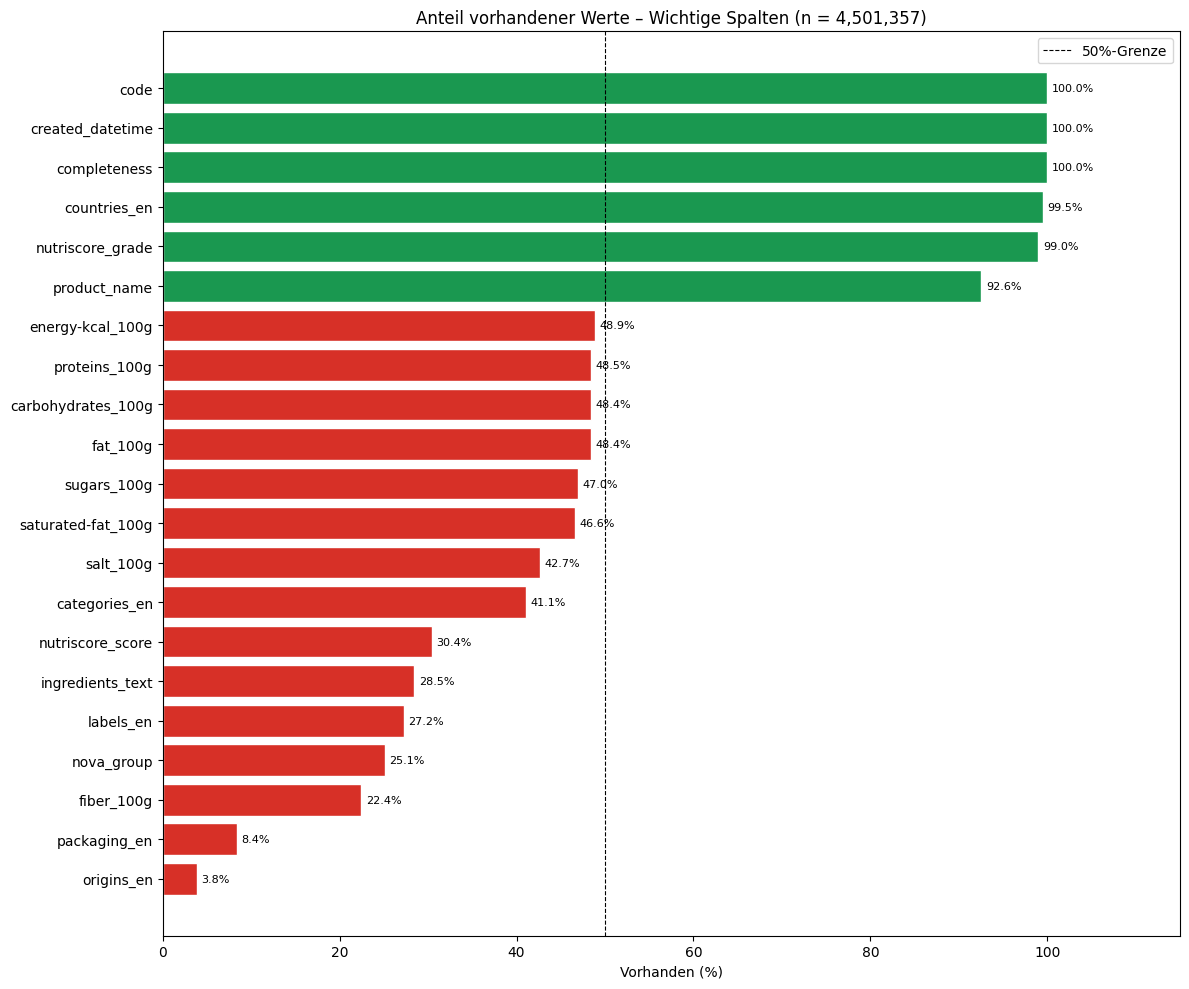

→ Grafik gespeichert: missing_values_wichtige_spalten.png


In [ ]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

CSV_PATH = "en.openfoodfacts.org.products 2.csv"

WICHTIGE_COLS = [
    "code", "product_name", "countries_en",
    "categories_en", "labels_en",
    "packaging_en",
    "nutriscore_grade", "nutriscore_score",
    "nova_group", "ecoscore_grade",
    "energy-kcal_100g", "fat_100g", "saturated-fat_100g",
    "sugars_100g", "fiber_100g", "proteins_100g", "salt_100g",
    "ingredients_text",
    "created_datetime", "completeness", "carbohydrates_100g", "origins_en"
]

print("⏳ Lade CSV mit wichtigen Spalten …")
df_wichtig = pd.read_csv(
    CSV_PATH,
    sep="\t",
    usecols=lambda c: c in WICHTIGE_COLS,
    low_memory=False,
    on_bad_lines="skip",
)
df_wichtig = df_wichtig[df_wichtig["code"].notna()].reset_index(drop=True)
print(f"✅ Geladen: {df_wichtig.shape[0]:,} Zeilen  |  {df_wichtig.shape[1]} Spalten\n")

# Vollständigkeit berechnen
total = len(df_wichtig)
filled_pct = (df_wichtig.notna().sum() / total * 100).sort_values(ascending=True)
filled_count = df_wichtig.notna().sum().reindex(filled_pct.index)

print("Vorhandene Werte pro Spalte:")
for col, pct, cnt in zip(filled_pct.index, filled_pct.values, filled_count.values):
    print(f"  {col:<35} {pct:5.1f}%  ({cnt:,} vorhanden)")

# Visualisierung
colors = ["#d73027" if v < 50 else "#1a9850" for v in filled_pct]
fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(filled_pct.index, filled_pct.values, color=colors, edgecolor="white")
for bar, val in zip(bars, filled_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)
ax.set_xlabel("Vorhanden (%)")
ax.set_title(f"Anteil vorhandener Werte – Wichtige Spalten (n = 4,501,355)")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50%-Grenze")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.savefig("missing_values_wichtige_spalten.png", dpi=150)
plt.show()
print("→ Grafik gespeichert: missing_values_wichtige_spalten.png")